In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
from pathlib import Path
import os
import json
import shutil
import random
import pandas as pd
from collections import Counter, defaultdict
from PIL import Image
import matplotlib.pyplot as plt

BASE_DIR = Path("/content/drive/MyDrive/DIS_PROJESI_007")

DENTEX_EXTRACTED = BASE_DIR / "data_extracted" / "dentex"
DENTEX_PREPARED = BASE_DIR / "data_prepared" / "dentex_yolo"

RESULTS_DIR = BASE_DIR / "results" / "dentex_prepare"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("DENTEX extracted:", DENTEX_EXTRACTED)
print("DENTEX prepared:", DENTEX_PREPARED)
print("Var mı?:", DENTEX_EXTRACTED.exists())

DENTEX extracted: /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex
DENTEX prepared: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo
Var mı?: True


In [3]:
def print_tree(root_path, max_depth=4, max_files_per_folder=10):
    root_path = Path(root_path)

    print("\nKlasör yapısı:", root_path)
    print("=" * 100)

    for current_root, dirs, files in os.walk(root_path):
        current_root = Path(current_root)
        depth = len(current_root.relative_to(root_path).parts)

        if depth > max_depth:
            dirs[:] = []
            continue

        indent = "    " * depth
        print(f"{indent}{current_root.name}/")

        file_indent = "    " * (depth + 1)
        for f in files[:max_files_per_folder]:
            print(f"{file_indent}{f}")

        if len(files) > max_files_per_folder:
            print(f"{file_indent}... {len(files) - max_files_per_folder} dosya daha")

print_tree(DENTEX_EXTRACTED, max_depth=4)


Klasör yapısı: /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex
dentex/
    training_data/
        training_data/
            quadrant-enumeration-disease/
                train_quadrant_enumeration_disease.json
                xrays/
                    train_0.png
                    train_1.png
                    train_10.png
                    train_100.png
                    train_101.png
                    train_102.png
                    train_103.png
                    train_104.png
                    train_105.png
                    train_106.png
                    ... 695 dosya daha
            quadrant/
                train_quadrant.json
                xrays/
                    train_0.png
                    train_1.png
                    train_10.png
                    train_100.png
                    train_101.png
                    train_102.png
                    train_103.png
                    train_104.png
                    train_105.

In [4]:
json_files = list(DENTEX_EXTRACTED.rglob("*.json"))
image_files = []

for ext in ["*.png", "*.jpg", "*.jpeg"]:
    image_files.extend(list(DENTEX_EXTRACTED.rglob(ext)))

print("JSON dosya sayısı:", len(json_files))
for p in json_files:
    print("-", p)

print("\nGörüntü dosya sayısı:", len(image_files))
for p in image_files[:10]:
    print("-", p)

JSON dosya sayısı: 3
- /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex/training_data/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json
- /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex/training_data/training_data/quadrant/train_quadrant.json
- /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex/training_data/training_data/quadrant_enumeration/train_quadrant_enumeration.json

Görüntü dosya sayısı: 3654
- /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex/training_data/training_data/quadrant-enumeration-disease/xrays/train_0.png
- /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex/training_data/training_data/quadrant-enumeration-disease/xrays/train_1.png
- /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex/training_data/training_data/quadrant-enumeration-disease/xrays/train_10.png
- /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex/training_data/training_data/quadrant-enumeration-

In [5]:
for json_path in json_files:
    print("\n" + "=" * 100)
    print("JSON:", json_path.name)
    print("=" * 100)

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("Tip:", type(data))

    if isinstance(data, dict):
        print("Anahtarlar:", list(data.keys()))

        for key, value in data.items():
            if isinstance(value, list):
                print(f"{key}: list, uzunluk = {len(value)}")
            elif isinstance(value, dict):
                print(f"{key}: dict, anahtar sayısı = {len(value)}")
            else:
                print(f"{key}: {type(value)}")
    elif isinstance(data, list):
        print("Liste uzunluğu:", len(data))
        if len(data) > 0:
            print("İlk eleman tipi:", type(data[0]))
            print("İlk eleman:", data[0])


JSON: train_quadrant_enumeration_disease.json
Tip: <class 'dict'>
Anahtarlar: ['images', 'annotations', 'categories_1', 'categories_2', 'categories_3']
images: list, uzunluk = 705
annotations: list, uzunluk = 3529
categories_1: list, uzunluk = 4
categories_2: list, uzunluk = 8
categories_3: list, uzunluk = 4

JSON: train_quadrant.json
Tip: <class 'dict'>
Anahtarlar: ['images', 'annotations', 'categories']
images: list, uzunluk = 693
annotations: list, uzunluk = 2772
categories: list, uzunluk = 4

JSON: train_quadrant_enumeration.json
Tip: <class 'dict'>
Anahtarlar: ['images', 'annotations', 'categories_1', 'categories_2']
images: list, uzunluk = 634
annotations: list, uzunluk = 18095
categories_1: list, uzunluk = 4
categories_2: list, uzunluk = 8


In [6]:
def show_json_sample(json_path, max_items=2):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("\n" + "=" * 100)
    print("JSON:", json_path.name)
    print("=" * 100)

    if isinstance(data, dict):
        for key, value in data.items():
            print("\nKEY:", key)
            print("TYPE:", type(value))

            if isinstance(value, list):
                print("LEN:", len(value))
                for item in value[:max_items]:
                    print(item)
                    print("-" * 60)

            elif isinstance(value, dict):
                print("DICT LEN:", len(value))
                sample_keys = list(value.keys())[:max_items]
                for sk in sample_keys:
                    print("Sample key:", sk)
                    print(value[sk])
                    print("-" * 60)

    elif isinstance(data, list):
        for item in data[:max_items]:
            print(item)
            print("-" * 60)

for json_path in json_files:
    show_json_sample(json_path, max_items=2)


JSON: train_quadrant_enumeration_disease.json

KEY: images
TYPE: <class 'list'>
LEN: 705
{'height': 1316, 'width': 2744, 'id': 1, 'file_name': 'train_673.png'}
------------------------------------------------------------
{'height': 1504, 'width': 2872, 'id': 2, 'file_name': 'train_283.png'}
------------------------------------------------------------

KEY: annotations
TYPE: <class 'list'>
LEN: 3529
{'iscrowd': 0, 'image_id': 1, 'bbox': [542.0, 698.0, 220.0, 271.0], 'segmentation': [[621, 703, 573, 744, 542, 885, 580, 945, 650, 969, 711, 883, 762, 807, 748, 741, 649, 698]], 'id': 1, 'area': 39683, 'category_id_1': 3, 'category_id_2': 7, 'category_id_3': 0}
------------------------------------------------------------
{'iscrowd': 0, 'image_id': 1, 'bbox': [1952.0, 693.0, 177.0, 270.0], 'segmentation': [[2045, 693, 2109, 734, 2129, 915, 2047, 963, 2009, 909, 1973, 851, 1955, 782, 1952, 730, 2000, 702]], 'id': 2, 'area': 33301, 'category_id_1': 2, 'category_id_2': 7, 'category_id_3': 0}
--

In [7]:
for json_path in json_files:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("\nJSON:", json_path.name)

    if isinstance(data, dict):
        keys = set(data.keys())

        if {"images", "annotations", "categories"}.issubset(keys):
            print("COCO formatına benziyor.")
            print("images:", len(data["images"]))
            print("annotations:", len(data["annotations"]))
            print("categories:", len(data["categories"]))
        else:
            print("COCO formatı gibi görünmüyor.")
            print("Anahtarlar:", keys)
    else:
        print("Dict değil.")


JSON: train_quadrant_enumeration_disease.json
COCO formatı gibi görünmüyor.
Anahtarlar: {'images', 'categories_1', 'annotations', 'categories_2', 'categories_3'}

JSON: train_quadrant.json
COCO formatına benziyor.
images: 693
annotations: 2772
categories: 4

JSON: train_quadrant_enumeration.json
COCO formatı gibi görünmüyor.
Anahtarlar: {'categories_1', 'annotations', 'images', 'categories_2'}


In [8]:
for json_path in json_files:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("\n" + "=" * 100)
    print("JSON:", json_path.name)
    print("=" * 100)

    if isinstance(data, dict) and "categories" in data:
        categories = data["categories"]
        print("Kategori sayısı:", len(categories))

        for cat in categories:
            print(cat)
    else:
        print("Bu JSON içinde categories alanı yok.")


JSON: train_quadrant_enumeration_disease.json
Bu JSON içinde categories alanı yok.

JSON: train_quadrant.json
Kategori sayısı: 4
{'id': 0, 'name': '2', 'supercategory': '2'}
{'id': 1, 'name': '1', 'supercategory': '1'}
{'id': 2, 'name': '3', 'supercategory': '3'}
{'id': 3, 'name': '4', 'supercategory': '4'}

JSON: train_quadrant_enumeration.json
Bu JSON içinde categories alanı yok.


In [9]:
for json_path in json_files:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("\n" + "=" * 100)
    print("JSON:", json_path.name)
    print("=" * 100)

    if isinstance(data, dict) and "annotations" in data:
        annotations = data["annotations"]
        print("Annotation sayısı:", len(annotations))

        if len(annotations) > 0:
            print("İlk annotation:")
            print(annotations[0])

            print("\nAnnotation anahtarları:")
            print(list(annotations[0].keys()))
    else:
        print("Bu JSON içinde annotations alanı yok.")


JSON: train_quadrant_enumeration_disease.json
Annotation sayısı: 3529
İlk annotation:
{'iscrowd': 0, 'image_id': 1, 'bbox': [542.0, 698.0, 220.0, 271.0], 'segmentation': [[621, 703, 573, 744, 542, 885, 580, 945, 650, 969, 711, 883, 762, 807, 748, 741, 649, 698]], 'id': 1, 'area': 39683, 'category_id_1': 3, 'category_id_2': 7, 'category_id_3': 0}

Annotation anahtarları:
['iscrowd', 'image_id', 'bbox', 'segmentation', 'id', 'area', 'category_id_1', 'category_id_2', 'category_id_3']

JSON: train_quadrant.json
Annotation sayısı: 2772
İlk annotation:
{'iscrowd': 0, 'image_id': 1, 'bbox': [1453.9245283018868, 332.2452830188679, 624.5283018867922, 467.92452830188677], 'segmentation': [[1474, 800, 1453, 473, 1931, 332, 2078, 539, 1789, 728]], 'category_id': 0, 'id': 1, 'area': 180569}

Annotation anahtarları:
['iscrowd', 'image_id', 'bbox', 'segmentation', 'category_id', 'id', 'area']

JSON: train_quadrant_enumeration.json
Annotation sayısı: 18095
İlk annotation:
{'iscrowd': 0, 'image_id': 1

In [10]:
for json_path in json_files:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("\n" + "=" * 100)
    print("JSON:", json_path.name)
    print("=" * 100)

    if isinstance(data, dict) and "images" in data:
        images = data["images"]
        print("Image kayıt sayısı:", len(images))

        if len(images) > 0:
            print("İlk image kaydı:")
            print(images[0])

            print("\nImage anahtarları:")
            print(list(images[0].keys()))
    else:
        print("Bu JSON içinde images alanı yok.")


JSON: train_quadrant_enumeration_disease.json
Image kayıt sayısı: 705
İlk image kaydı:
{'height': 1316, 'width': 2744, 'id': 1, 'file_name': 'train_673.png'}

Image anahtarları:
['height', 'width', 'id', 'file_name']

JSON: train_quadrant.json
Image kayıt sayısı: 693
İlk image kaydı:
{'height': 1316, 'width': 2965, 'id': 1, 'file_name': 'train_673.png'}

Image anahtarları:
['height', 'width', 'id', 'file_name']

JSON: train_quadrant_enumeration.json
Image kayıt sayısı: 634
İlk image kaydı:
{'height': 1316, 'width': 2710, 'id': 1, 'file_name': 'train_283.png'}

Image anahtarları:
['height', 'width', 'id', 'file_name']


In [11]:
for i, p in enumerate(json_files):
    print(i, "→", p.name)

0 → train_quadrant_enumeration_disease.json
1 → train_quadrant.json
2 → train_quadrant_enumeration.json


In [12]:
main_json_path = None

for p in json_files:
    if "quadrant-enumeration-disease" in p.name or "quadrant_enumeration_disease" in p.name:
        main_json_path = p
        break

print("Seçilen ana JSON:", main_json_path)

if main_json_path is None:
    raise FileNotFoundError("Ana disease JSON bulunamadı. JSON dosya adlarını kontrol et.")

Seçilen ana JSON: /content/drive/MyDrive/DIS_PROJESI_007/data_extracted/dentex/training_data/training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json


In [13]:
with open(main_json_path, "r", encoding="utf-8") as f:
    dentex_data = json.load(f)

print("Anahtarlar:", dentex_data.keys())
print("Image sayısı:", len(dentex_data.get("images", [])))
print("Annotation sayısı:", len(dentex_data.get("annotations", [])))
print("Kategori sayısı:", len(dentex_data.get("categories", [])))

Anahtarlar: dict_keys(['images', 'annotations', 'categories_1', 'categories_2', 'categories_3'])
Image sayısı: 705
Annotation sayısı: 3529
Kategori sayısı: 0


In [17]:
categories_1 = dentex_data["categories_1"]
categories_2 = dentex_data["categories_2"]
categories_3 = dentex_data["categories_3"]

df_categories_1 = pd.DataFrame(categories_1)
df_categories_2 = pd.DataFrame(categories_2)
df_categories_3 = pd.DataFrame(categories_3)

print("categories_1 - Quadrant:")
display(df_categories_1)

print("categories_2 - Enumeration / Tooth number:")
display(df_categories_2)

print("categories_3 - Disease:")
display(df_categories_3)

categories_1 - Quadrant:


,id,name,supercategory
0,0,1,1
1,1,2,2
2,2,3,3
3,3,4,4


categories_2 - Enumeration / Tooth number:


,id,name,supercategory
0,0,1,1
1,1,2,2
2,2,3,3
3,3,4,4
4,4,5,5
5,5,6,6
6,6,7,7
7,7,8,8


categories_3 - Disease:


,id,name,supercategory
0,0,Impacted,Impacted
1,1,Caries,Caries
2,2,Periapical Lesion,Periapical Lesion
3,3,Deep Caries,Deep Caries


In [15]:
print(type(dentex_data))

if isinstance(dentex_data, dict):
    print("Ana anahtarlar:")
    print(dentex_data.keys())

    print("\nİlk seviye içerik özeti:")
    for k, v in dentex_data.items():
        print(k, "->", type(v), end=" ")
        if isinstance(v, list):
            print("len:", len(v))
        elif isinstance(v, dict):
            print("len:", len(v))
        else:
            print()
else:
    print("dentex_data dict değil.")

<class 'dict'>
Ana anahtarlar:
dict_keys(['images', 'annotations', 'categories_1', 'categories_2', 'categories_3'])

İlk seviye içerik özeti:
images -> <class 'list'> len: 705
annotations -> <class 'list'> len: 3529
categories_1 -> <class 'list'> len: 4
categories_2 -> <class 'list'> len: 8
categories_3 -> <class 'list'> len: 4


In [16]:
for k, v in dentex_data.items():
    print("\n" + "="*80)
    print("KEY:", k)
    print("TYPE:", type(v))

    if isinstance(v, list):
        print("LEN:", len(v))
        if len(v) > 0:
            print("İlk eleman:")
            print(v[0])

    elif isinstance(v, dict):
        print("DICT LEN:", len(v))
        sample_keys = list(v.keys())[:5]
        print("İlk keyler:", sample_keys)
        for sk in sample_keys[:2]:
            print("\nSample key:", sk)
            print(v[sk])


KEY: images
TYPE: <class 'list'>
LEN: 705
İlk eleman:
{'height': 1316, 'width': 2744, 'id': 1, 'file_name': 'train_673.png'}

KEY: annotations
TYPE: <class 'list'>
LEN: 3529
İlk eleman:
{'iscrowd': 0, 'image_id': 1, 'bbox': [542.0, 698.0, 220.0, 271.0], 'segmentation': [[621, 703, 573, 744, 542, 885, 580, 945, 650, 969, 711, 883, 762, 807, 748, 741, 649, 698]], 'id': 1, 'area': 39683, 'category_id_1': 3, 'category_id_2': 7, 'category_id_3': 0}

KEY: categories_1
TYPE: <class 'list'>
LEN: 4
İlk eleman:
{'id': 0, 'name': '1', 'supercategory': '1'}

KEY: categories_2
TYPE: <class 'list'>
LEN: 8
İlk eleman:
{'id': 0, 'name': '1', 'supercategory': '1'}

KEY: categories_3
TYPE: <class 'list'>
LEN: 4
İlk eleman:
{'id': 0, 'name': 'Impacted', 'supercategory': 'Impacted'}


In [18]:
annotations = dentex_data["annotations"]

disease_counter = Counter([ann["category_id_3"] for ann in annotations])

disease_id_to_name = {}

for cat in categories_3:
    disease_id_to_name[cat["id"]] = cat["name"]

rows = []

for disease_id, count in disease_counter.items():
    rows.append({
        "disease_id": disease_id,
        "disease_name": disease_id_to_name.get(disease_id, "unknown"),
        "count": count
    })

df_disease_counts = pd.DataFrame(rows).sort_values("count", ascending=False)
df_disease_counts

,disease_id,disease_name,count
1,1,Caries,2189
0,0,Impacted,604
3,3,Deep Caries,578
2,2,Periapical Lesion,158


In [19]:
image_ann_counter = Counter([ann["image_id"] for ann in annotations])

df_image_ann = pd.DataFrame([
    {"image_id": image_id, "annotation_count": count}
    for image_id, count in image_ann_counter.items()
])

df_image_ann.describe()

,image_id,annotation_count
count,678.000000,678.000000
mean,353.715339,5.205015
std,204.317013,3.322299
min,1.000000,1.000000
25%,175.250000,3.000000
50%,353.500000,5.000000
75%,530.750000,7.000000
max,705.000000,23.000000


In [20]:
images = dentex_data["images"]

df_images = pd.DataFrame(images)
df_images.head()

,height,width,id,file_name
0,1316,2744,1,train_673.png
1,1504,2872,2,train_283.png
2,1316,2909,3,train_435.png
3,1504,2872,4,train_95.png
4,1504,2872,5,train_475.png


In [21]:
print("Image kayıtlarından ilk 20 dosya adı:")

for img in images[:20]:
    print(img)

Image kayıtlarından ilk 20 dosya adı:
{'height': 1316, 'width': 2744, 'id': 1, 'file_name': 'train_673.png'}
{'height': 1504, 'width': 2872, 'id': 2, 'file_name': 'train_283.png'}
{'height': 1316, 'width': 2909, 'id': 3, 'file_name': 'train_435.png'}
{'height': 1504, 'width': 2872, 'id': 4, 'file_name': 'train_95.png'}
{'height': 1504, 'width': 2872, 'id': 5, 'file_name': 'train_475.png'}
{'height': 1316, 'width': 2867, 'id': 6, 'file_name': 'train_62.png'}
{'height': 1536, 'width': 3076, 'id': 7, 'file_name': 'train_637.png'}
{'height': 1316, 'width': 2815, 'id': 8, 'file_name': 'train_187.png'}
{'height': 1316, 'width': 2928, 'id': 9, 'file_name': 'train_509.png'}
{'height': 1504, 'width': 2872, 'id': 10, 'file_name': 'train_31.png'}
{'height': 1316, 'width': 2910, 'id': 11, 'file_name': 'train_498.png'}
{'height': 1316, 'width': 2866, 'id': 12, 'file_name': 'train_264.png'}
{'height': 1316, 'width': 2788, 'id': 13, 'file_name': 'train_581.png'}
{'height': 1504, 'width': 2868, 'id': 

In [22]:
all_images_by_name = {}

for img_path in image_files:
    all_images_by_name[img_path.name] = img_path

print("Toplam görüntü dosyası:", len(all_images_by_name))

matched = 0
not_matched = []

for img in images:
    file_name = img.get("file_name")
    file_base = Path(file_name).name

    if file_base in all_images_by_name:
        matched += 1
    else:
        not_matched.append(file_name)

print("JSON image sayısı:", len(images))
print("Eşleşen görüntü:", matched)
print("Eşleşmeyen:", len(not_matched))

print("\nEşleşmeyen ilk 20:")
for item in not_matched[:20]:
    print(item)

Toplam görüntü dosyası: 1622
JSON image sayısı: 705
Eşleşen görüntü: 705
Eşleşmeyen: 0

Eşleşmeyen ilk 20:


In [23]:
bbox_lengths = Counter()

for ann in annotations:
    bbox = ann.get("bbox", None)
    if bbox is not None:
        bbox_lengths[len(bbox)] += 1

print("BBox uzunluk dağılımı:", bbox_lengths)

print("\nİlk 10 bbox:")
for ann in annotations[:10]:
    print(ann.get("bbox"))

BBox uzunluk dağılımı: Counter({4: 3529})

İlk 10 bbox:
[542.0, 698.0, 220.0, 271.0]
[1952.0, 693.0, 177.0, 270.0]
[675.0, 708.0, 243.0, 300.0]
[1463.0, 725.0, 98.0, 425.0]
[1536.0, 753.0, 103.0, 381.0]
[1600.0, 762.0, 122.0, 337.0]
[1701.0, 371.0, 145.0, 290.0]
[779.0, 376.0, 132.0, 317.0]
[1667.0, 723.0, 237.0, 356.0]
[1806.0, 696.0, 237.0, 308.0]


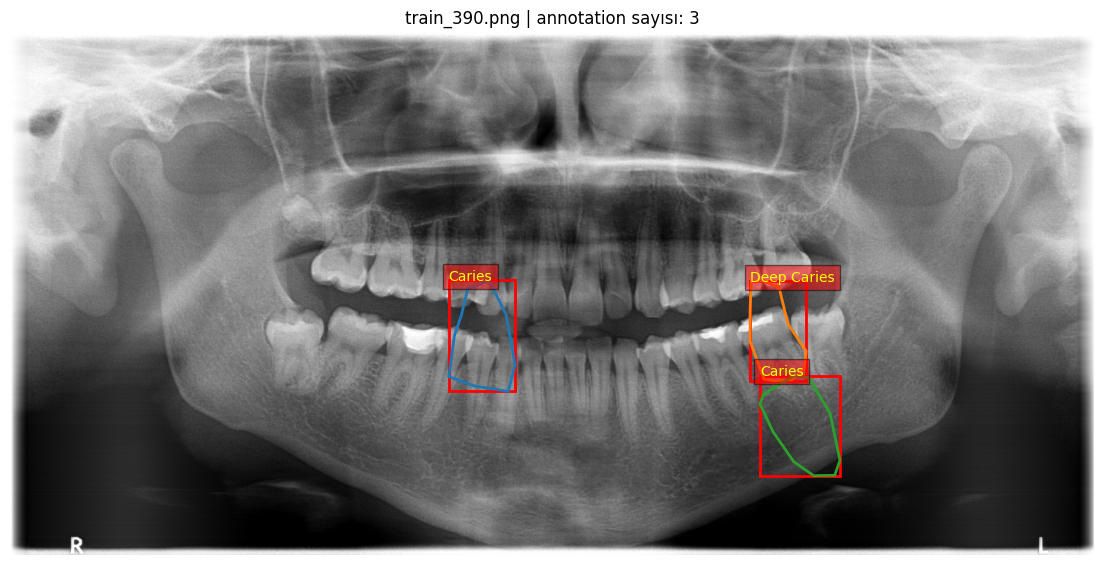

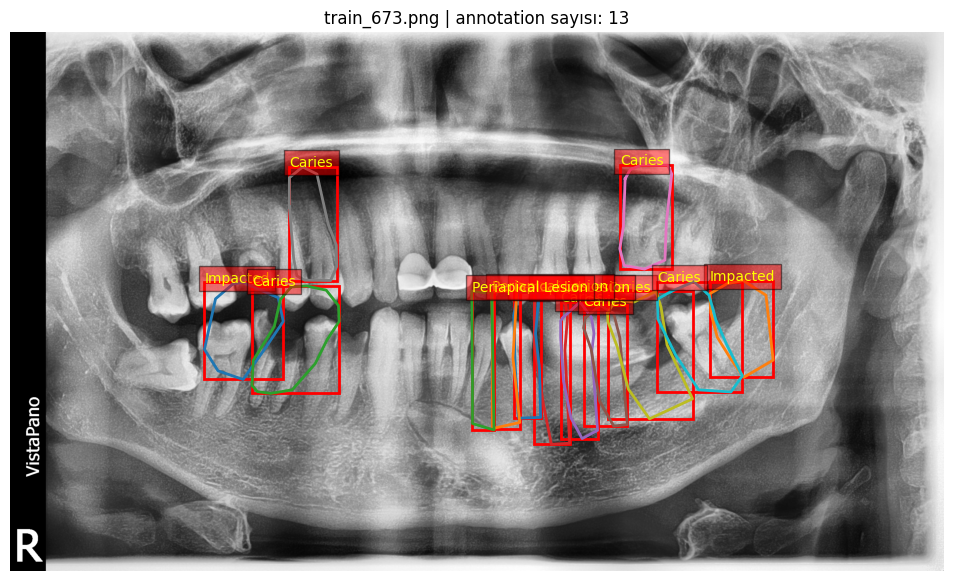

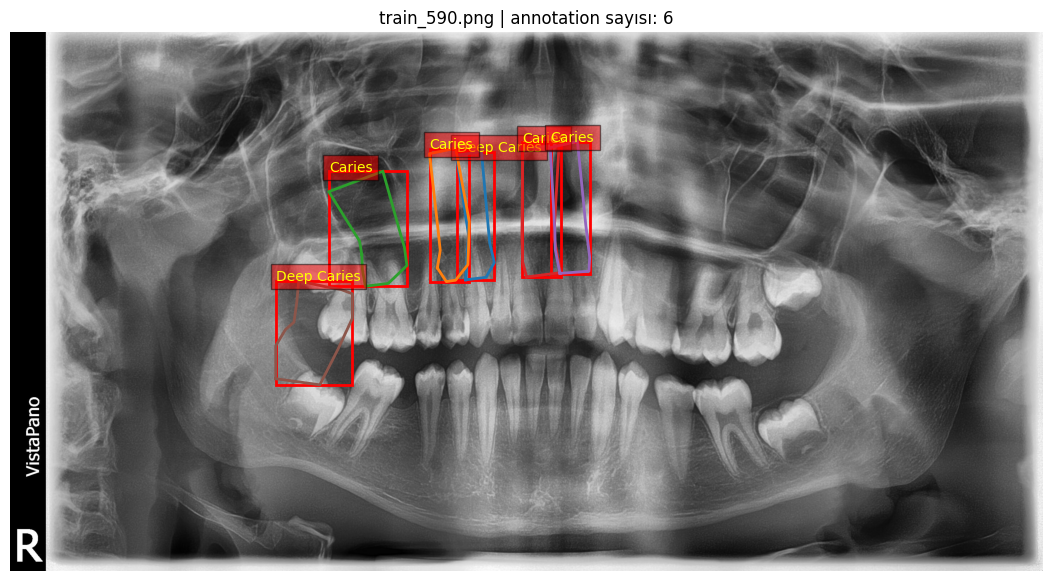

In [26]:
def show_random_annotated_image_with_polygon():
    sample_ann = random.choice(annotations)
    image_id = sample_ann["image_id"]

    img_info = id_to_image[image_id]
    file_name = img_info["file_name"]

    img_path = find_image_path(file_name)

    if img_path is None:
        print("Görüntü bulunamadı:", file_name)
        return

    img = Image.open(img_path).convert("RGB")

    fig, ax = plt.subplots(1, figsize=(14, 7))
    ax.imshow(img, cmap="gray")

    anns_for_image = [ann for ann in annotations if ann["image_id"] == image_id]

    for ann in anns_for_image:
        disease_id = ann["category_id_3"]
        disease_name = disease_id_to_name.get(disease_id, str(disease_id))

        # BBOX çiz
        x, y, w, h = ann["bbox"]
        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        # POLYGON çiz
        segmentation = ann.get("segmentation", [])

        if len(segmentation) > 0:
            for seg in segmentation:
                xs = seg[0::2]
                ys = seg[1::2]
                ax.plot(xs + [xs[0]], ys + [ys[0]], linewidth=2)

        ax.text(
            x,
            y,
            disease_name,
            color="yellow",
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.5)
        )

    ax.set_title(f"{file_name} | annotation sayısı: {len(anns_for_image)}")
    ax.axis("off")
    plt.show()

for _ in range(3):
    show_random_annotated_image_with_polygon()

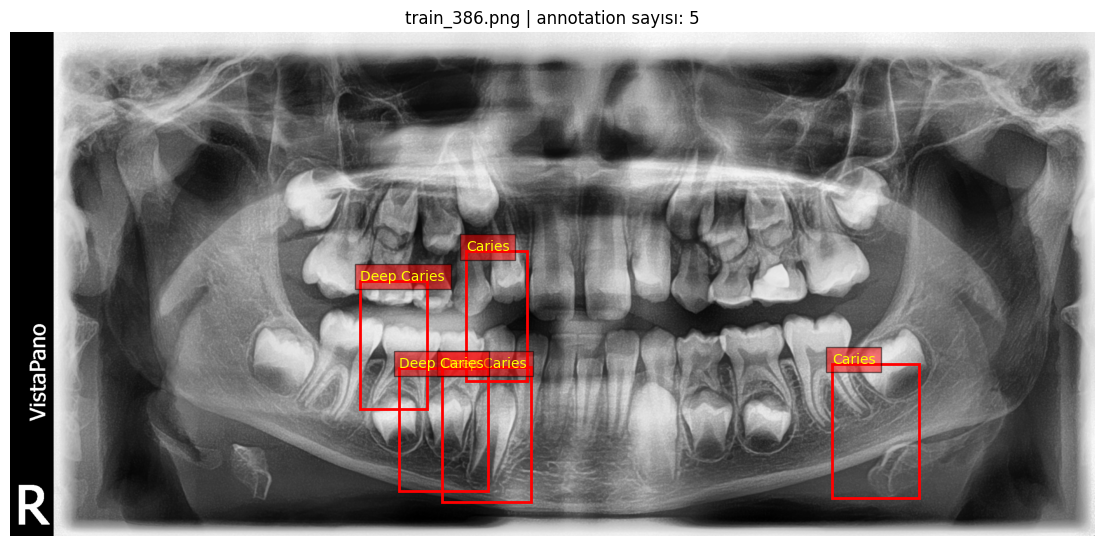

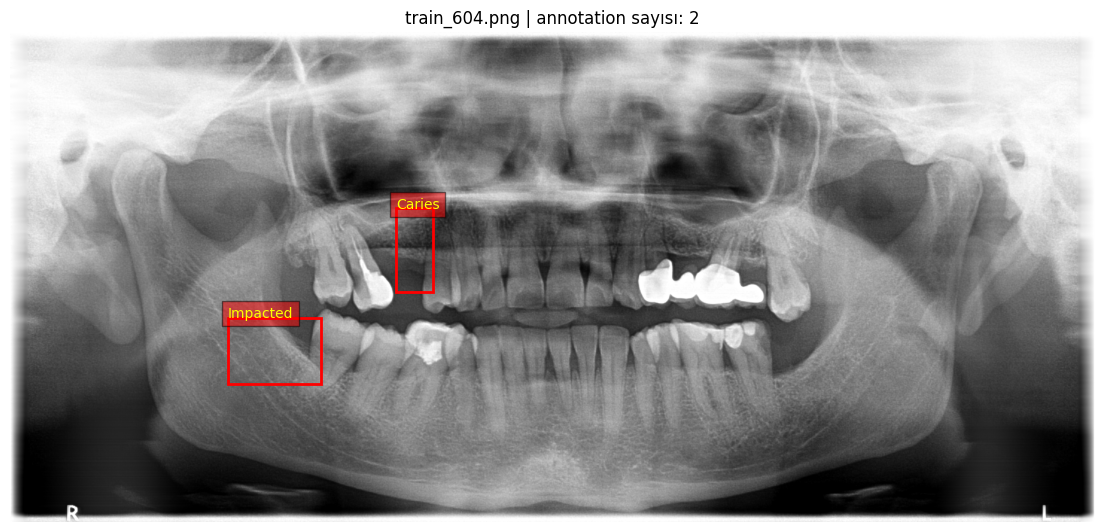

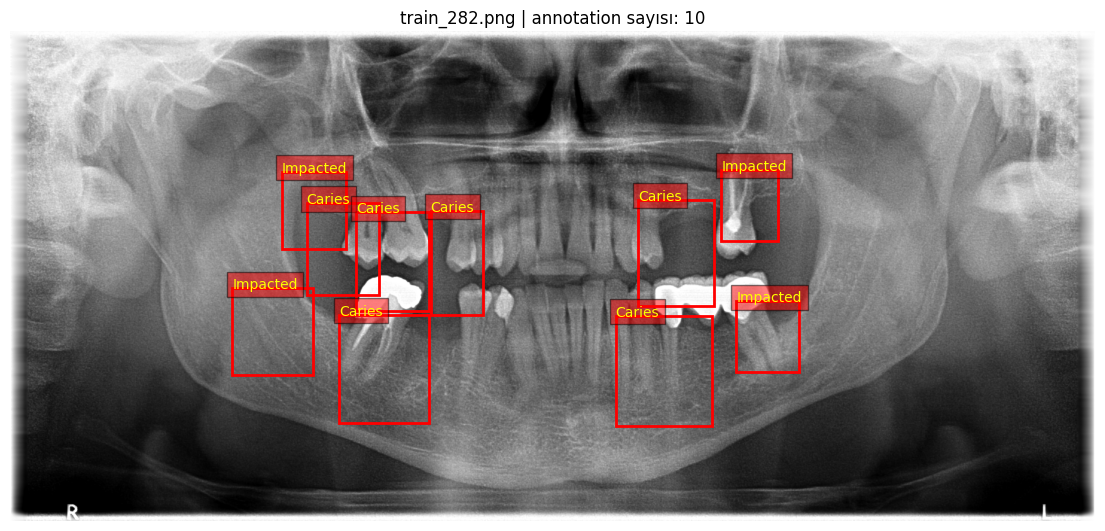

In [27]:
import matplotlib.patches as patches

id_to_image = {img["id"]: img for img in images}

def find_image_path(file_name):
    file_base = Path(file_name).name
    return all_images_by_name.get(file_base, None)

def show_random_annotated_image():
    sample_ann = random.choice(annotations)
    image_id = sample_ann["image_id"]

    img_info = id_to_image[image_id]
    file_name = img_info["file_name"]

    img_path = find_image_path(file_name)

    if img_path is None:
        print("Görüntü bulunamadı:", file_name)
        return

    img = Image.open(img_path).convert("RGB")

    fig, ax = plt.subplots(1, figsize=(14, 7))
    ax.imshow(img, cmap="gray")

    anns_for_image = [ann for ann in annotations if ann["image_id"] == image_id]

    for ann in anns_for_image:
        bbox = ann["bbox"]
        x, y, w, h = bbox

        disease_id = ann["category_id_3"]
        disease_name = disease_id_to_name.get(disease_id, str(disease_id))

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)
        ax.text(
            x,
            y,
            disease_name,
            color="yellow",
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.5)
        )

    ax.set_title(f"{file_name} | annotation sayısı: {len(anns_for_image)}")
    ax.axis("off")
    plt.show()

for _ in range(3):
    show_random_annotated_image()

In [28]:
df_categories_1.to_csv(RESULTS_DIR / "dentex_categories_1_quadrant.csv", index=False)
df_categories_2.to_csv(RESULTS_DIR / "dentex_categories_2_enumeration.csv", index=False)
df_categories_3.to_csv(RESULTS_DIR / "dentex_categories_3_disease.csv", index=False)

df_disease_counts.to_csv(RESULTS_DIR / "dentex_disease_counts.csv", index=False)
df_images.to_csv(RESULTS_DIR / "dentex_images.csv", index=False)
df_image_ann.to_csv(RESULTS_DIR / "dentex_image_annotation_counts.csv", index=False)

print("Kaydedildi:")
print(RESULTS_DIR)

Kaydedildi:
/content/drive/MyDrive/DIS_PROJESI_007/results/dentex_prepare


In [29]:
# DENTEX disease id'leri:
# 0: Impacted
# 1: Caries
# 2: Periapical Lesion
# 3: Deep Caries

TARGET_DISEASES = {
    1: 0,  # Caries -> YOLO class 0
    3: 1,  # Deep Caries -> YOLO class 1
    2: 2   # Periapical Lesion -> YOLO class 2
}

YOLO_CLASS_NAMES = {
    0: "caries",
    1: "deep_caries",
    2: "periapical_lesion"
}

EXCLUDED_DISEASES = {
    0: "Impacted"
}

print("Kullanılacak sınıflar:")
for old_id, new_id in TARGET_DISEASES.items():
    print(f"DENTEX disease_id {old_id} -> YOLO class {new_id}: {YOLO_CLASS_NAMES[new_id]}")

print("\nÇıkarılan sınıflar:")
for old_id, name in EXCLUDED_DISEASES.items():
    print(f"DENTEX disease_id {old_id}: {name}")

Kullanılacak sınıflar:
DENTEX disease_id 1 -> YOLO class 0: caries
DENTEX disease_id 3 -> YOLO class 1: deep_caries
DENTEX disease_id 2 -> YOLO class 2: periapical_lesion

Çıkarılan sınıflar:
DENTEX disease_id 0: Impacted


In [30]:
target_annotations = []

for ann in annotations:
    disease_id = ann["category_id_3"]

    if disease_id in TARGET_DISEASES:
        target_annotations.append(ann)

print("Toplam annotation:", len(annotations))
print("Kullanılacak annotation:", len(target_annotations))
print("Çıkarılan annotation:", len(annotations) - len(target_annotations))

target_counter = Counter([ann["category_id_3"] for ann in target_annotations])

rows = []
for disease_id, count in target_counter.items():
    rows.append({
        "dentex_disease_id": disease_id,
        "disease_name": disease_id_to_name[disease_id],
        "yolo_class_id": TARGET_DISEASES[disease_id],
        "count": count
    })

df_target_counts = pd.DataFrame(rows).sort_values("yolo_class_id")
df_target_counts

Toplam annotation: 3529
Kullanılacak annotation: 2925
Çıkarılan annotation: 604


,dentex_disease_id,disease_name,yolo_class_id,count
0,1,Caries,0,2189
2,3,Deep Caries,1,578
1,2,Periapical Lesion,2,158


In [31]:
target_image_ids = sorted(list(set([ann["image_id"] for ann in target_annotations])))

print("Hedef annotation içeren görüntü sayısı:", len(target_image_ids))

target_images = [img for img in images if img["id"] in target_image_ids]

df_target_images = pd.DataFrame(target_images)
df_target_images.head()

Hedef annotation içeren görüntü sayısı: 662


,height,width,id,file_name
0,1316,2744,1,train_673.png
1,1504,2872,2,train_283.png
2,1504,2872,4,train_95.png
3,1504,2872,5,train_475.png
4,1316,2867,6,train_62.png


In [32]:
def coco_bbox_to_yolo(bbox, img_width, img_height):
    """
    COCO bbox formatı:
    [x_min, y_min, width, height]

    YOLO bbox formatı:
    x_center_norm y_center_norm width_norm height_norm
    """
    x, y, w, h = bbox

    x_center = x + w / 2
    y_center = y + h / 2

    x_center_norm = x_center / img_width
    y_center_norm = y_center / img_height
    w_norm = w / img_width
    h_norm = h / img_height

    return x_center_norm, y_center_norm, w_norm, h_norm

In [33]:
random.seed(42)

target_images_shuffled = target_images.copy()
random.shuffle(target_images_shuffled)

n_total = len(target_images_shuffled)
n_train = int(n_total * 0.70)
n_val = int(n_total * 0.18)
n_test = n_total - n_train - n_val

train_images = target_images_shuffled[:n_train]
val_images = target_images_shuffled[n_train:n_train + n_val]
test_images = target_images_shuffled[n_train + n_val:]

print("Toplam:", n_total)
print("Train:", len(train_images))
print("Val:", len(val_images))
print("Test:", len(test_images))

Toplam: 662
Train: 463
Val: 119
Test: 80


In [34]:
DENTEX_PREPARED = BASE_DIR / "data_prepared" / "dentex_yolo_3class"

# Önce eski klasör varsa temizleyelim
if DENTEX_PREPARED.exists():
    shutil.rmtree(DENTEX_PREPARED)

for split in ["train", "val", "test"]:
    (DENTEX_PREPARED / "images" / split).mkdir(parents=True, exist_ok=True)
    (DENTEX_PREPARED / "labels" / split).mkdir(parents=True, exist_ok=True)

print("YOLO klasörü oluşturuldu:")
print(DENTEX_PREPARED)

YOLO klasörü oluşturuldu:
/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class


In [35]:
# annotationları image_id'ye göre grupla
anns_by_image_id = defaultdict(list)

for ann in target_annotations:
    anns_by_image_id[ann["image_id"]].append(ann)

def prepare_split_yolo(split_name, split_images):
    copied_images = 0
    written_labels = 0
    skipped_images = 0

    for img_info in split_images:
        image_id = img_info["id"]
        file_name = img_info["file_name"]
        img_width = img_info["width"]
        img_height = img_info["height"]

        src_img_path = find_image_path(file_name)

        if src_img_path is None:
            skipped_images += 1
            continue

        dst_img_path = DENTEX_PREPARED / "images" / split_name / Path(file_name).name
        dst_label_path = DENTEX_PREPARED / "labels" / split_name / (Path(file_name).stem + ".txt")

        # Görüntüyü kopyala
        shutil.copy2(src_img_path, dst_img_path)
        copied_images += 1

        yolo_lines = []

        for ann in anns_by_image_id[image_id]:
            disease_id = ann["category_id_3"]

            if disease_id not in TARGET_DISEASES:
                continue

            yolo_class_id = TARGET_DISEASES[disease_id]
            bbox = ann["bbox"]

            x_center, y_center, w_norm, h_norm = coco_bbox_to_yolo(
                bbox,
                img_width,
                img_height
            )

            # Güvenlik: 0-1 aralığına kırp
            x_center = max(0, min(1, x_center))
            y_center = max(0, min(1, y_center))
            w_norm = max(0, min(1, w_norm))
            h_norm = max(0, min(1, h_norm))

            line = f"{yolo_class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}"
            yolo_lines.append(line)

        if len(yolo_lines) > 0:
            dst_label_path.write_text("\n".join(yolo_lines))
            written_labels += 1
        else:
            # Hedef etiketi yoksa görüntüyü ve boş etiketi kullanmıyoruz
            if dst_img_path.exists():
                dst_img_path.unlink()
            skipped_images += 1

    print(f"\n{split_name.upper()}")
    print("Kopyalanan görüntü:", copied_images)
    print("Yazılan label:", written_labels)
    print("Atlanan görüntü:", skipped_images)

prepare_split_yolo("train", train_images)
prepare_split_yolo("val", val_images)
prepare_split_yolo("test", test_images)


TRAIN
Kopyalanan görüntü: 463
Yazılan label: 463
Atlanan görüntü: 0

VAL
Kopyalanan görüntü: 119
Yazılan label: 119
Atlanan görüntü: 0

TEST
Kopyalanan görüntü: 80
Yazılan label: 80
Atlanan görüntü: 0


In [36]:
def count_yolo_split(split):
    img_dir = DENTEX_PREPARED / "images" / split
    label_dir = DENTEX_PREPARED / "labels" / split

    images_count = len(list(img_dir.glob("*")))
    labels_count = len(list(label_dir.glob("*.txt")))

    return images_count, labels_count

rows = []

for split in ["train", "val", "test"]:
    img_count, label_count = count_yolo_split(split)
    rows.append({
        "split": split,
        "images": img_count,
        "labels": label_count
    })

df_yolo_summary = pd.DataFrame(rows)
df_yolo_summary

,split,images,labels
0,train,463,463
1,val,119,119
2,test,80,80


In [37]:
yolo_class_counter = Counter()

for label_path in (DENTEX_PREPARED / "labels").rglob("*.txt"):
    lines = label_path.read_text().strip().splitlines()

    for line in lines:
        if line.strip() == "":
            continue
        cls_id = int(line.split()[0])
        yolo_class_counter[cls_id] += 1

rows = []

for cls_id, count in yolo_class_counter.items():
    rows.append({
        "class_id": cls_id,
        "class_name": YOLO_CLASS_NAMES[cls_id],
        "count": count
    })

df_yolo_class_counts = pd.DataFrame(rows).sort_values("class_id")
df_yolo_class_counts

,class_id,class_name,count
0,0,caries,2189
2,1,deep_caries,578
1,2,periapical_lesion,158


In [38]:
data_yaml = f"""
path: {DENTEX_PREPARED}
train: images/train
val: images/val
test: images/test

names:
  0: caries
  1: deep_caries
  2: periapical_lesion
"""

data_yaml_path = DENTEX_PREPARED / "data.yaml"
data_yaml_path.write_text(data_yaml.strip())

print(data_yaml_path)
print("\nİçerik:")
print(data_yaml_path.read_text())

/content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class/data.yaml

İçerik:
path: /content/drive/MyDrive/DIS_PROJESI_007/data_prepared/dentex_yolo_3class
train: images/train
val: images/val
test: images/test

names:
  0: caries
  1: deep_caries
  2: periapical_lesion


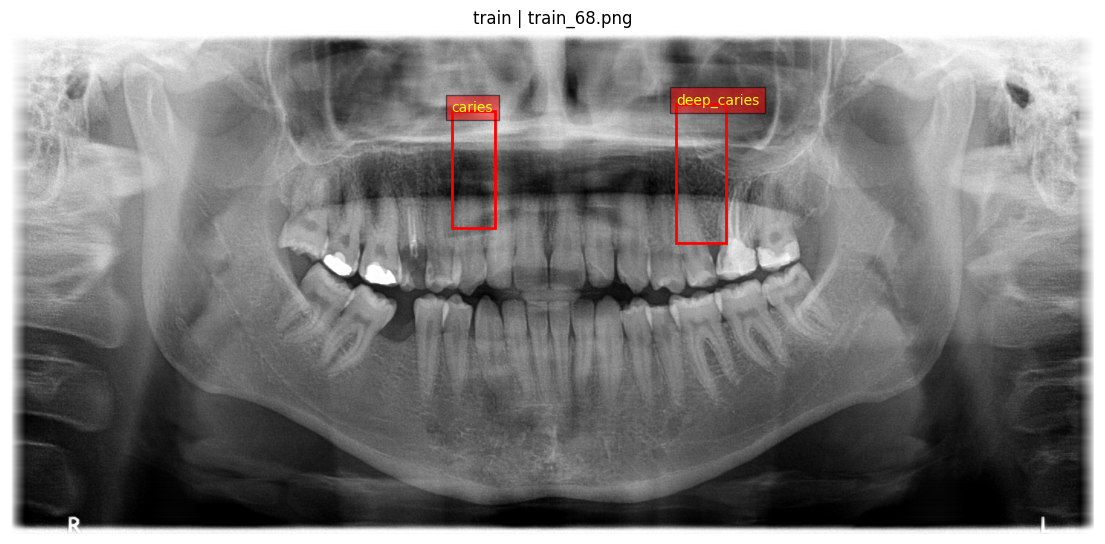

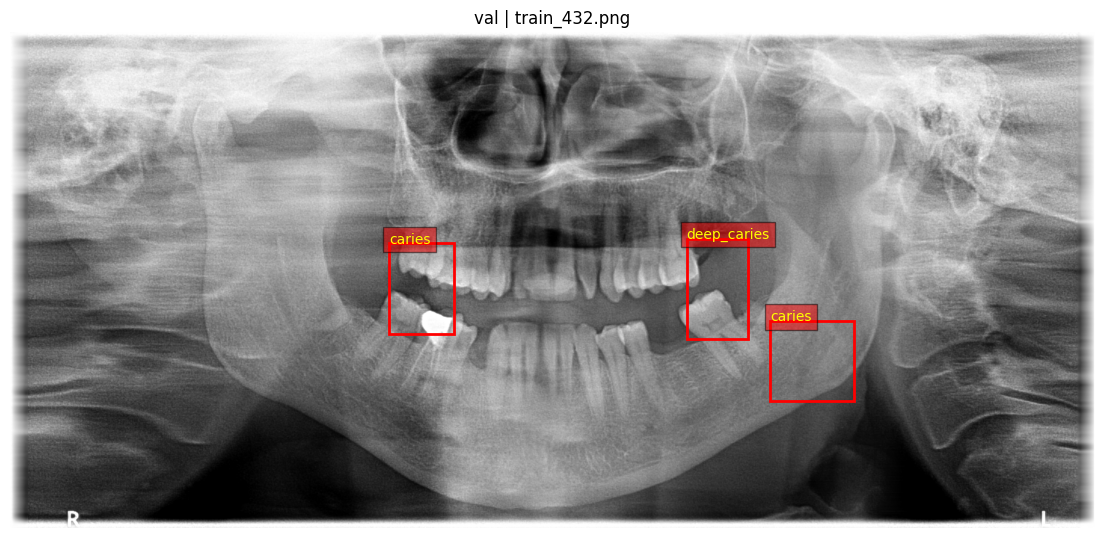

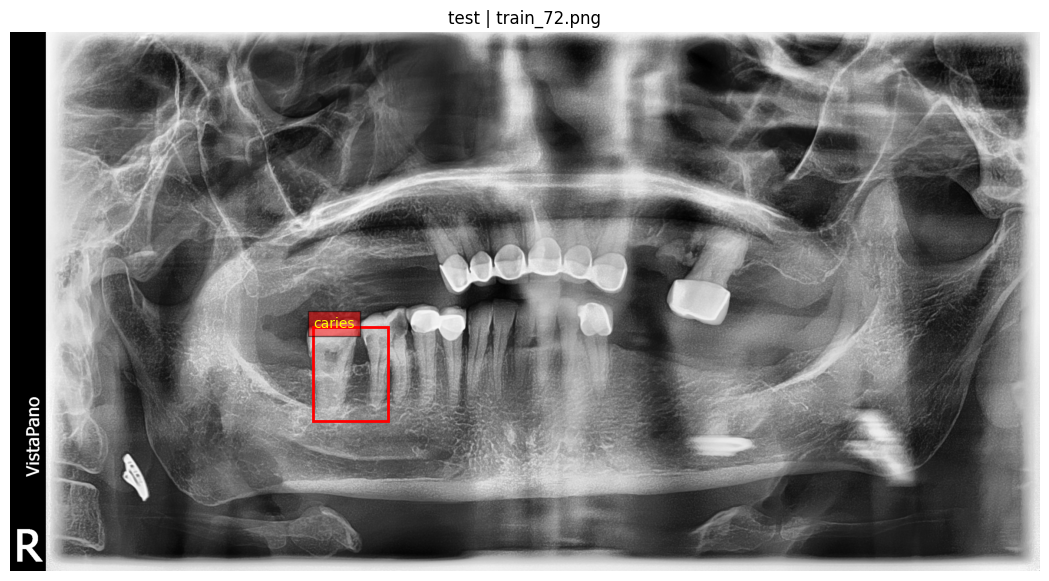

In [39]:
def show_prepared_yolo_sample(split="train"):
    img_dir = DENTEX_PREPARED / "images" / split
    label_dir = DENTEX_PREPARED / "labels" / split

    img_paths = list(img_dir.glob("*"))
    img_path = random.choice(img_paths)

    label_path = label_dir / (img_path.stem + ".txt")

    img = Image.open(img_path).convert("RGB")
    img_width, img_height = img.size

    fig, ax = plt.subplots(1, figsize=(14, 7))
    ax.imshow(img, cmap="gray")

    if label_path.exists():
        lines = label_path.read_text().strip().splitlines()

        for line in lines:
            parts = line.split()
            cls_id = int(parts[0])
            x_center, y_center, w_norm, h_norm = map(float, parts[1:])

            box_w = w_norm * img_width
            box_h = h_norm * img_height
            x_min = x_center * img_width - box_w / 2
            y_min = y_center * img_height - box_h / 2

            rect = patches.Rectangle(
                (x_min, y_min),
                box_w,
                box_h,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )
            ax.add_patch(rect)

            ax.text(
                x_min,
                y_min,
                YOLO_CLASS_NAMES[cls_id],
                color="yellow",
                fontsize=10,
                bbox=dict(facecolor="red", alpha=0.5)
            )

    ax.set_title(f"{split} | {img_path.name}")
    ax.axis("off")
    plt.show()

for split in ["train", "val", "test"]:
    show_prepared_yolo_sample(split)